### Initialize the Environment:
##### Virtual Environment Commands

| Command | Linux/Mac | GitBash |
| ------- | --------- | ------- |
| Create | `python3 -m venv venv` | `python -m venv venv` |
| Activate | `source venv/bin/activate` | `source venv/Scripts/activate` |
| Install | `pip install -r requirements.txt` | `pip install -r requirements.txt` |
| Deactivate | `deactivate` | `deactivate` |
##### Select the Kernel (This will be in the Requirements.txt eventually)

Using the venv (Python 3.13.2) located  in venv/bin/python)

### **Project Overview & Plan**
Capstone Project for Code:You Data Analysis track. This project analyzes Beer Recipes for frequency of uploads for various beer styles, while capturing preferences of strength, hopiness and batch size.    The goal of the project is to demonstrate a general knowledge of Python (Pandas, Numpy, MatLibPlot, Seaborn, Wordcloud), Cursor and ChatGPT.
**Data Sources:**

The datasets used in this project are all related to online beer recipes. One dataset contains the different styles of beer as recognized by the Beer Judge Certification Program (BJCP.org).
- [Beersmith Recipes](https://beersmithrecipes.com/recent/) - scraped data that contains certain fields of 100% of the all grain beer recipes that have been uploaded by users.

- [Brewers Friend All-Grain Recipes](https://www.brewersfriend.com/homebrew-recipes/all-grain/) - scraped data that contains select fields of 100% of the all-grain beer recipes that have been uploaded by users.

- [BJCP - Judging Styles of Beer](https://github.com/ascholer/bjcp-styleview/blob/main/styles.json) - dataset that contains the criteria used to judge beer. Will help determine if recipes meet the criteria to be considered a specific style of beer.

### **Import Data** and preview Data shapes

In [28]:
import pandas as pd
import re  # Imported "re" Python module to assist with parsing the data with pattern matching
from pandas import DataFrame
from typing import (
    Optional,
)  # received warning about "float | None" when my type hint only included "float"
import inspect
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import numpy as np
import rich as rch
import seaborn as sns
from wordcloud import WordCloud
from rich.console import Console
from rich.table import Table

In [29]:
bs_df = pd.read_csv("Input_Files/beersmith_recipes.csv")
bf_df = pd.read_csv("Input_Files/bf_recipes.csv")
styles_2021 = pd.read_json("Input_Files/styles_2021.json")

In [30]:
print(bs_df.shape)
print(bf_df.shape)
print(styles_2021.shape)
print(styles_2021.head)

(63121, 5)
(215580, 8)
(116, 28)
<bound method NDFrame.head of                        name number                       category  \
0                   Altbier     7B     Amber Bitter European Beer   
1    Alternative Grain Beer    31A  Alternative Fermentables Beer   
2    Alternative Sugar Beer    31B  Alternative Fermentables Beer   
3        American Amber Ale    19A  Amber And Brown American Beer   
4       American Barleywine    22C            Strong American Ale   
..                      ...    ...                            ...   
111               Wheatwine    22D            Strong American Ale   
112     Wild Specialty Beer    28C              American Wild Ale   
113    Winter Seasonal Beer    30C                    Spiced Beer   
114                 Witbier    24A                    Belgian Ale   
115          Wood-Aged Beer    33A                      Wood Beer   

     categorynumber                                  overallimpression  \
0                 7  A moderately 

### **Data Cleanup**

#### **BJCP Styles -** styles_2021.json = styles_2021

In [31]:
# Count of nulls in each column
print(styles_2021.isnull().sum())

name                           0
number                         0
category                       0
categorynumber                 0
overallimpression              0
aroma                          0
appearance                     0
flavor                         0
mouthfeel                      0
comments                       0
history                        0
characteristicingredients      0
stylecomparison                0
ibumin                        20
ibumax                        20
ogmin                         20
ogmax                         20
fgmin                         20
fgmax                         20
abvmin                        20
abvmax                        20
srmmin                        20
srmmax                        20
commercialexamples             0
tags                           0
entryinstructions             86
currentlydefinedtypes        115
strengthclassifications      115
dtype: int64


In [32]:
print(styles_2021.columns)

Index(['name', 'number', 'category', 'categorynumber', 'overallimpression',
       'aroma', 'appearance', 'flavor', 'mouthfeel', 'comments', 'history',
       'characteristicingredients', 'stylecomparison', 'ibumin', 'ibumax',
       'ogmin', 'ogmax', 'fgmin', 'fgmax', 'abvmin', 'abvmax', 'srmmin',
       'srmmax', 'commercialexamples', 'tags', 'entryinstructions',
       'currentlydefinedtypes', 'strengthclassifications'],
      dtype='object')


In [33]:
# The nulls that show up are a feature and not a lack of data so the nulls will not be rectified
# Some beer styles are not judged strictly by numerical categories (ABV, IBU, FG, OG, SRM)
# because these styles are broad and diverse. They can encompass a wide range of
# characteristics, making it impractical to define them using fixed numerical constraints.
# Instead, these styles are often evaluated based on overall balance, tradition, and
# sensory attributes rather than rigid technical specifications. Therefore these styles of beer will
# be excluded from graphic representations where appropriate

styles_2021_cleaned = styles_2021.copy()

# Count null values for each column
null_counts = styles_2021_cleaned.isnull().sum()

# Filter columns with null counts greater than zero
columns_with_nulls = null_counts[null_counts > 0].index.tolist()

# print(null_counts)
# print(columns_with_nulls)

In [34]:
def clean_styles_data(df, columns_to_drop, column_mapping) -> pd.DataFrame:
    """
    Part of the cleanup:
        Retaining needed columns
        Renaming columns to make them communicate same data as recipe datasets

    Parameters:
    df: The Dataframe we are dropping columns
    columns_to_drop: dropping the unneeded columns
    columns_to_rename: for better conformity to recipe datasets
    """

    # delete the specified columns
    df.drop(columns=columns_to_drop, axis=1, inplace=True)

    # Renaming columns
    df.rename(columns=column_mapping, inplace=True)

    return df

In [35]:
# Columns to drop in dataframe style_2021_cleaned
cols_to_drop = [
    "overallimpression",
    "aroma",
    "appearance",
    "flavor",
    "mouthfeel",
    "comments",
    "history",
    "characteristicingredients",
    "stylecomparison",
    "srmmin",
    "srmmax",
    "commercialexamples",
    "tags",
    "entryinstructions",
    "currentlydefinedtypes",
    "strengthclassifications",
]

# Columns to rename and the new name
column_mapping = {"name": "Style", "number": "Style Number", "category": "Category"}

styles_2021_cleaned = clean_styles_data(
    styles_2021_cleaned, cols_to_drop, column_mapping
)
# styles_2021_cleaned


#### **Beer Smith Recipes -** beersmith_recipes.csv = bs_df
Will analyze data, delete duplicates, remove what appears to be test data, resolve missing data, split the stats column into the individual components to match up with the Brewers friend data. While cleaning up the data, will create a function to clean up the data in the other datasets. In the Beer Smith data there were 31 rows missing the Recipe Name. Since the name wasn't crucial to the analysis of the recipes, but the recipe information was still of value, we assigned a generic name to each of the rows missing the Recipe Name.

**Determine Null Values**

In [36]:
# Create a copy for cleaning the dataframe
bs_df_cleaned = bs_df.copy()

# Count null values for each column
null_counts = bs_df_cleaned.isnull().sum()

# Filter columns with null counts greater than zero
columns_with_nulls = null_counts[null_counts > 0].index.tolist()

print(null_counts)
print(columns_with_nulls)
print(bs_df.shape)

Recipe Name    31
Recipe URL      0
Beer Style      0
Brewer          0
Stats           0
dtype: int64
['Recipe Name']
(63121, 5)


**Replace Null Values**

In [37]:
# This function is to replace null values in the Recipe Name Column with a Generic
# unique name that begins with the first 2 characters of the dataframe name and is
# incremented by 1 to keep the name unique. This was done because the data in the
# rest of the columns contributed to the data and analysis.
# This code was written with a lot of back and forth with Perplexity.ai.
# I don't fully understand the code, and it's kicking up 2 problems but
# because I could have just dropped the rows and since the code is working I'm
# going to leave as is.

def replace_column_nulls(df, target_column):
    # Replace nulls in one specific column with unique numbered values
    # Get dataframe variable name safely
    try:
        caller_frame = inspect.currentframe().f_back  # type: ignore
        df_name = [k for k, v in caller_frame.f_locals.items() if v is df][0]  # type: ignore
        prefix = df_name[:2].upper()
    except (AttributeError, IndexError):  # Catch only relevant errors
        prefix = "DF"
    
    # Create column-specific generator
    def col_generator():
        counter = 1
        while True:
            yield f"{prefix} No Name {counter}"
            counter += 1

    # Only process specified column
    mask = df[target_column].isnull()
    num_nulls = mask.sum()

    if num_nulls > 0:
        gen = col_generator()
        replacements = [next(gen) for _ in range(num_nulls)]
        df.loc[mask, target_column] = replacements

        # Show changes
        print(f"Replaced {num_nulls} nulls in {target_column}")
        print("Example replacement:", replacements[0])

    return df

In [38]:
# Call the function
bf_df_cleaned = replace_column_nulls(bs_df_cleaned, "Recipe Name")

Replaced 31 nulls in Recipe Name
Example replacement: BS No Name 1


In [39]:
print(bs_df.shape)

(63121, 5)


**Delete duplicates and other rows with unusable data**


In [40]:
def clean_bs_df(df) -> DataFrame:
    """
     Further Clean the Beer Smith DataFrame by deleting duplicates and eliminating
     rows with no value in the 'Beer Style' column.
    """
    # Create a copy for cleaning the dataframe
    # bs_df_cleaned = bs_df.copy()

    # Delete all duplicates based on the value in the column "Recipe URL"
    df.drop_duplicates(
        subset=["Recipe URL"], keep="first", inplace=True, ignore_index=True
    )

    # Eliminate rows with no value in column 'Beer Style'. In Data Wrangler I noticed columns with only a 
    # pair of parentheses in the column.
    df = df[df["Beer Style"] != "()"]
 
    # Reset the index to ensure it is in order
    df.reset_index(drop=True, inplace=True)
    
    print(bs_df_cleaned.info())
    
    return df

In [41]:
# Clean the Beer Smith DataFrame
bs_df_cleaned = clean_bs_df(bs_df_cleaned)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56768 entries, 0 to 56767
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Recipe Name  56768 non-null  object
 1   Recipe URL   56768 non-null  object
 2   Beer Style   56768 non-null  object
 3   Brewer       56768 non-null  object
 4   Stats        56768 non-null  object
dtypes: object(5)
memory usage: 2.2+ MB
None


**Splitting the Stats & Beer Style columns into individual columns of Data:**
Beer Style "Dark Mild (13A)"
Stats "OG: 1.073 (17.7° P), Bitterness: 34.5 IBUs, ABV: 6.9 %"

| Style|Style Number|
|:----------:|:----------:|
| Dark Mild| 13A| 

| OG| Plato| IBU| ABV|FG |
|:----------:|:----------:|:----------:|:----------:|:----------:|
| 1.073| 17.7| 34.5 | 6.9 |Calc|


In [42]:
def parse_columns(df: pd.DataFrame) -> pd.DataFrame:
    def extract_values(row: pd.Series) -> pd.Series:
        stats = row["Stats"]
        beer_style = row["Beer Style"]

        # Regex pattern to split "Style" format
        style_match = re.match(r"(.*?)\s*\((.*?)\)", beer_style)  # type: ignore

        return pd.Series(
            {
                "Style": style_match.group(1).strip() if style_match else None,
                "Style Number": style_match.group(2) if style_match else None,
                "OG": extract_float(stats, r"OG: (\d+\.\d+)"),
                "Plato": extract_float(stats, r"(\d+\.\d+)° P"),
                "IBU": extract_float(stats, r"Bitterness: (\d+\.\d+)"),
                "ABV": extract_float(stats, r"ABV: (\d+\.\d+)"),
            }
        )  # type: ignore

    # received a warning about "float | None" and Perplexity.ai explained why and how to fix

    def extract_float(text: str, pattern: str) -> Optional[float]:
        match = re.search(pattern, text)
        return float(match.group(1)) if match else None

    new_columns = df.apply(extract_values, axis=1)
    df = pd.concat([df, new_columns], axis=1)  # Add new extracted columns
    df = df.drop(
        columns=["Beer Style", "Stats", "Recipe URL", "Brewer"]
    )  # Drop original columns
    
    # Eliminate all rows with "0" in the 'ABV' column (couldn't clean earlier because the 'ABV' column
    # didn't exist)
    df = df[df["ABV"] >= 1]
    
    # Reset the index to ensure it is in order
    df.reset_index(drop=True, inplace=True)

    return df

In [43]:
# Run function to split the 'Stats' and 'Beer Style" column into several columns for analysis and
# formatting
# The contents of the 'Stats' column was comma delimited with embedded headers
# The contents of the 'Beer Style' column had a style and a style number
bs_df_cleaned = parse_columns(bs_df_cleaned)

In [44]:
print(bs_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56419 entries, 0 to 56418
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Recipe Name   56419 non-null  object 
 1   Style         56419 non-null  object 
 2   Style Number  56419 non-null  object 
 3   OG            56419 non-null  float64
 4   Plato         56419 non-null  float64
 5   IBU           56419 non-null  float64
 6   ABV           56419 non-null  float64
dtypes: float64(4), object(3)
memory usage: 3.0+ MB
None


**Balling Formula for Final Gravity (FG) Calculation (ChatGPT)**<br><br>
To estimate the **Final Gravity (FG)** using the **Original Gravity (OG) in Plato (°P)** and the **Alcohol by Volume (ABV)**, we will use the **Balling formula**:


-Step 1: Calculate Residual Extract (re) in degrees Plato
re = (plato / 1.25) - (abv / 0.79)

-Step 2: Convert re from degrees Plato to Specific Gravity (SG)
fg = 1 + (re / (258.6 - ((re / 258.2) * 227.1)))


In [45]:
def calculate_final_gravity(plato, abv):
    """
    Calculate Final Gravity (FG) using the Balling formula. Not sure if Plato will be needed,
    however it exists in the Brewers Friend Data and this will make them compatible.

    Parameters:
    plato (float): Original Gravity in degrees Plato.
    abv (float): Alcohol by volume percentage.
    re (float): Residual Extract in degrees Plato.

    Returns:
    float: Estimated Final Gravity (FG).
    """
    # Step 1: Calculate Residual Extract (RE) in degrees Plato
    re = (plato / 1.25) - (abv / 0.79)

    # Step 2: Convert RE from degrees Plato to Specific Gravity (SG)
    fg = 1 + (re / (258.6 - ((re / 258.2) * 227.1)))

    return fg


def add_final_gravity_column(df):
    """
    Add a new column 'FG' to the DataFrame with calculated Final Gravity.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'Plato' and 'ABV' columns.

    Returns:
    None: Modifies the DataFrame in place by adding a new column 'FG'.
    """
    # Apply the calculate_final_gravity function on every row, creating a new column
    # and locating it after the Plato column to match the Brewers Friend data frame
    plato_index = df.columns.get_loc("Plato")
    df.insert(
        loc=plato_index + 1,
        column="FG",
        value=df.apply(
            lambda row: round(calculate_final_gravity(row["Plato"], row["ABV"]), 3),
            axis=1,
        ),
    )

In [46]:
add_final_gravity_column(bs_df_cleaned)
print(bs_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56419 entries, 0 to 56418
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Recipe Name   56419 non-null  object 
 1   Style         56419 non-null  object 
 2   Style Number  56419 non-null  object 
 3   OG            56419 non-null  float64
 4   Plato         56419 non-null  float64
 5   FG            56419 non-null  float64
 6   IBU           56419 non-null  float64
 7   ABV           56419 non-null  float64
dtypes: float64(5), object(3)
memory usage: 3.4+ MB
None


In [47]:
bs_df_cleaned

,Recipe Name,Style,Style Number,OG,Plato,FG,IBU,ABV
0,Super Magnifico Mexican Lager 8g - Solo v1,Cream Ale,1C,1.044,10.9,1.011,15.2,4.7
1,Clemens Honey Stout - 12 gal,Imperial Stout,20C,1.097,23.2,1.023,74.4,10.0
2,Modelo Especial,Vienna Lager,7A,1.045,11.2,1.013,14.4,4.5
3,GammaRay,New England IPA,21B,1.060,14.9,1.017,64.5,6.0
4,Rockaway Chocolate Peanut Butter Stout 2 Batch 2,Sweet Stout,16A,1.059,14.5,1.009,29.5,7.3
...,...,...,...,...,...,...,...,...
56414,Garbage Brown,American Brown Ale,10C,1.053,13.0,1.016,27.1,5.0
56415,Mild (110),Mild,11A,1.031,7.8,1.010,19.2,2.9
56416,Simcoe Mild (99),Mild,11A,1.031,7.8,1.010,13.9,2.9
56417,"Malted Bliss, Wedding Barley Wine",English Barleywine,19B,1.137,31.5,1.025,45.9,15.0


In [48]:
# Since there are only 116 styles of beer per the BJCP Style Guide we grouped on Style
# to see how many styles we have. Not pretty...we ended up having 586 styles.

grouped_style = bs_df_cleaned.groupby('Style')

grouped_styles = grouped_style.size()
grouped_styles

Style
                                           11
Adventures in Homebrewing - Grain List      1
Altbier                                   138
Alternative Grain Beer                     33
Alternative Sugar Beer                     11
                                         ... 
Бельгийский светлый                         1
Вайцен/Вайсбир                              1
Крепкий портер                              2
Октоберфест/мерцен                          2
Специальный/лучший/премиум биттер           1
Length: 585, dtype: int64

#### **Excess styles and incorrect style numbers in the DataFrame** 
There are only 116 Styles of beer per the 2021 BJCP Style Guide not the 586 that exist in the Beersmith DataFrame. Since we are going to analyze beer styles as part of our project we will need to standardize the data to conform to the current accepted styles. (part of my approach was to manually create a lookup table, in excel, to update incorrect style numbers. This enabled more than 10,000 rows to stay in the data. However, it was very time consuming and I would not repeat in future. I would try and create a formulaic way of keeping some of the additional data)  
**Reasons for excess number of styles:** 
- Previous Style Guides have evolved to the current styles (2015, 2008). Names changed for existing beers
- Input into the online recipe sites was not controlled - pick from dropdown or add your own
- On the user added styles, the user may have duplicated a style and spelled their entry incorrectly
- Styles may be correct but entered in a foreign language

**Feature to fix excess styles**

- Update all rows that have the correct style name to also have the correct style number
- Update older style names (from previous style guides) to the current style name , i.e., 'Kentucky Common' to 'Historical Beer: Kentucky Common', 
- Create a lookup excel file with the most common discrepancies to update to current standard
    - Language differences , i.e., 'Kölsch' to 'Kolsch', 'Märzen' instead of 'Marzen'
    - Styles that were introduced since last style guide update, but weren't in previous style guides, , i.e., 'New England IPA' to 'Hazy IPA'

In [49]:
def update_style_data(df, excel_file, dfname):

    # Read in excel file to fix the 'Style' discrepancies
    df_update = pd.read_excel(excel_file)  

    # Ensure expected column names exist in the update file
    expected_columns = ['Style', 'New Style', 'New Style Number']
    if not all(col in df_update.columns for col in expected_columns):
        raise ValueError(f"Excel file must contain columns: {expected_columns}")

    # Merge on "Style" column
    df = df.merge(df_update, on='Style', how='left', suffixes=('', '_update'))

    # Update values where a match is found
    df['Style'] = df['New Style'].combine_first(df['Style'])
    df['Style Number'] = df['New Style Number'].combine_first(df['Style Number'])
 
    # After all of the previous cleaning and look ups, anything left with missing values are either
    # wines, ciders, meads or errors that only affect a small number of rows. So they are being deleted.
    df = df.dropna(subset=['New Style Number'])   

    # Drop temporary columns
    df = df.drop(columns=['New Style', 'New Style Number']).reset_index(drop=True)
    
    # Adding a column to identify the data source the recipe originated from

    df['Source'] = dfname
    
    print(df.info())
    
    return df
 



In [50]:
# Call the function with the dataframe to be cleaned and the excel file with the lookups
# Also passing in a name to populate the 'Origin'
dfname = "bs_df"
bs_df_cleaned = update_style_data(bs_df_cleaned, "Input_Files/BJCP_Updated.xlsx", dfname)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54111 entries, 0 to 54110
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Recipe Name   54111 non-null  object 
 1   Style         54111 non-null  object 
 2   Style Number  54111 non-null  object 
 3   OG            54111 non-null  float64
 4   Plato         54111 non-null  float64
 5   FG            54111 non-null  float64
 6   IBU           54111 non-null  float64
 7   ABV           54111 non-null  float64
 8   Source        54111 non-null  object 
dtypes: float64(5), object(4)
memory usage: 3.7+ MB
None


In [51]:
bs_df_cleaned

,Recipe Name,Style,Style Number,OG,Plato,FG,IBU,ABV,Source
0,Super Magnifico Mexican Lager 8g - Solo v1,Cream Ale,1C,1.044,10.9,1.011,15.2,4.7,bs_df
1,Clemens Honey Stout - 12 gal,Imperial Stout,20C,1.097,23.2,1.023,74.4,10.0,bs_df
2,Modelo Especial,Vienna Lager,7A,1.045,11.2,1.013,14.4,4.5,bs_df
3,GammaRay,Hazy IPA,21C,1.060,14.9,1.017,64.5,6.0,bs_df
4,Rockaway Chocolate Peanut Butter Stout 2 Batch 2,Sweet Stout,16A,1.059,14.5,1.009,29.5,7.3,bs_df
...,...,...,...,...,...,...,...,...,...
54106,Mild (110),Dark Mild,13A,1.031,7.8,1.010,19.2,2.9,bs_df
54107,Simcoe Mild (99),Dark Mild,13A,1.031,7.8,1.010,13.9,2.9,bs_df
54108,"Malted Bliss, Wedding Barley Wine",English Barley Wine,17D,1.137,31.5,1.025,45.9,15.0,bs_df
54109,"Malted Bliss, Wedding Barley Wine",English Barley Wine,17D,1.137,31.5,1.025,45.9,15.0,bs_df


In [52]:
grouped_style = bs_df_cleaned.groupby('Style')

grouped_styles = grouped_style.size()
print(grouped_styles.info)

<bound method Series.info of Style
Altbier                    212
Alternative Grain Beer     158
Alternative Sugar Beer      11
American Amber Ale        2731
American Barleywine        278
                          ... 
Wheatwine                   24
Wild Specialty Beer         23
Winter Seasonal Beer       143
Witbier                    948
Wood-Aged Beer               7
Length: 114, dtype: int64>


#### **Brewers Friend Recipes -** bf_recipes.csv = bf_df
Will analyze data, delete duplicates, remove what appears to be test data, resolve missing data and rename columns to match up with the BeerSmith column names. In the Brewers friend data there are 14 null values in the title column. Since the name isn't crucial to the analysis of the recipes, but the recipe information is still of value, I  assigned a generic name to each of the rows missing the Title.

In [53]:
def clean_recipe_data(
    df,
    columns_to_drop,
    column_mapping,
    location,
    column_name,
    formula,
    location_2,
    column_name_2,
    new_column_2,
) -> pd.DataFrame:
    """
    Part of the cleanup:
        Creating a copy of dataframe with cleaned up data
        Removing unneeded columns
        Renaming columns to match with other dataframes
        Adding column with complex calculation


    Parameters:
    df: The Dataframes we are dropping columns
    columns_to_drop: the columns we don't need
    columns_to_rename: the columns to rename so they are common between the 2 data sets


    """
    # List of columns to drop by index
    # cols_to_drop = [2, 7, ]

    # Drop the specified columns
    df.drop(df.columns[columns_to_drop], axis=1, inplace=True)

    # Adding a new column named with a formula to create calculated value
    # match up with the other dataframes
    df.rename(columns=column_mapping, inplace=True)

    # Calculate the new column
    new_column = df.eval(formula)

    # Round up to 1 decimal place
    new_column = new_column.apply(lambda x: round(x, 1))

    # Insert the new column at the specified location with calculated value
    df.insert(location, column_name, new_column)

    # Insert another new column with no data for future calculations
    df.insert(location_2, column_name_2, new_column_2)
    # print(df.info)

    return df

In [54]:
# Columns to drop in bf_df_cleaned
cols_to_drop = [2, 7]

# Columns to rename and the new name
column_mapping = {"Title": "Recipe Name"}

# Add column for plato and calculate values to populate
location = 3
column_name = "Plato"
formula = "-463.37 + (668.72 * OG) - (205.35 * OG**2)"

# Add column to match other recipe dataset
location_2 = 2
column_name_2 = "Style Number"
new_column_2 = None


bf_df_cleaned = clean_recipe_data(
    bf_df,
    cols_to_drop,
    column_mapping,
    location,
    column_name,
    formula,
    location_2,
    column_name_2,
    new_column_2,
)
bf_df_cleaned


,Recipe Name,Style,Style Number,OG,Plato,FG,ABV,IBU
0,Avg. Perfect Northeast IPA (NEIPA),Specialty IPA: New England IPA,None,1.062,15.2,1.013,6.50,59.26
1,Sierra Nevada Pale Ale Clone,American Pale Ale,None,1.055,13.6,1.013,5.58,39.79
2,Vanilla Cream Ale,Cream Ale,None,1.055,13.6,1.013,5.48,19.44
3,Zombie Dust Clone - ALL GRAIN,American IPA,None,1.061,15.0,1.016,5.94,62.42
4,Russian River Pliny The Elder (original),Imperial IPA,None,1.072,17.5,1.018,7.09,232.89
...,...,...,...,...,...,...,...,...
215575,Awesome Recipe,American IPA,None,1.054,13.3,1.010,5.82,19.23
215576,Dildo NEIPA,Specialty IPA: New England IPA,None,1.061,15.0,1.012,6.43,18.70
215577,Double Down,Specialty IPA: New England IPA,None,1.082,19.8,1.015,8.83,28.76
215578,AGAIN,American IPA,None,1.029,7.3,1.010,2.51,60.87


In [55]:
print(bf_df_cleaned.shape)

(215580, 8)


In [56]:
# Function to delete rows that don't contain information or have incorrect values
# Incorrect values are values that aren't possible. For example can't have an OG > 1.250
def delete_useless_rows(df, column_name, condition):
    # This function will delete rows that contain unusable data
    if isinstance(condition, str):
        # For string conditions, use str.contains
        df = df[~df[column_name].str.contains(condition, case=False, na=False)]
    else:
        df = df[~df[column_name].apply(condition)]
    return df

In [57]:
# Parameters for removing useless rows

# Removing when there is no style to work with
column_name = "Style"
condition = "No Profile Selected" # type: ignore
bf_df_cleaned = delete_useless_rows(bf_df_cleaned, column_name, condition)

# Removing rows when the data is out of range
column_name = "OG"
def condition(x):
    return x > 1.25
bf_df_cleaned = delete_useless_rows(bf_df_cleaned, column_name, condition)

bf_df_cleaned

,Recipe Name,Style,Style Number,OG,Plato,FG,ABV,IBU
0,Avg. Perfect Northeast IPA (NEIPA),Specialty IPA: New England IPA,None,1.062,15.2,1.013,6.50,59.26
1,Sierra Nevada Pale Ale Clone,American Pale Ale,None,1.055,13.6,1.013,5.58,39.79
2,Vanilla Cream Ale,Cream Ale,None,1.055,13.6,1.013,5.48,19.44
3,Zombie Dust Clone - ALL GRAIN,American IPA,None,1.061,15.0,1.016,5.94,62.42
4,Russian River Pliny The Elder (original),Imperial IPA,None,1.072,17.5,1.018,7.09,232.89
...,...,...,...,...,...,...,...,...
215575,Awesome Recipe,American IPA,None,1.054,13.3,1.010,5.82,19.23
215576,Dildo NEIPA,Specialty IPA: New England IPA,None,1.061,15.0,1.012,6.43,18.70
215577,Double Down,Specialty IPA: New England IPA,None,1.082,19.8,1.015,8.83,28.76
215578,AGAIN,American IPA,None,1.029,7.3,1.010,2.51,60.87


In [58]:
# This function is to replace null values in the Recipe Name Column with a Generic
# unique name that begins with the first 2 characters of the dataframe name and is
# incremented by 1 to keep the name unique. This was done because the data in the
# rest of the columns contributed to the data and analysis.
# This code was written with a lot of back and forth with Perplexity.ai.

def replace_column_nulls(df, target_column):
    # Replace nulls in one specific column with unique numbered values
    # Get dataframe variable name safely
    try:
        caller_frame = inspect.currentframe().f_back  # type: ignore
        df_name = [k for k, v in caller_frame.f_locals.items() if v is df][0]  # type: ignore
        prefix = df_name[:2].upper()
    except (AttributeError, IndexError):  # Catch only relevant errors
        prefix = "DF"
        

    # Create column-specific generator
    def col_generator():
        counter = 1
        while True:
            yield f"{prefix} No Name {counter}"
            counter += 1

    # Only process specified column
    mask = df[target_column].isnull()
    num_nulls = mask.sum()

    if num_nulls > 0:
        gen = col_generator()
        replacements = [next(gen) for _ in range(num_nulls)]
        df.loc[mask, target_column] = replacements

        # Show changes
        print(f"Replaced {num_nulls} nulls in {target_column}")
        print("Example replacement:", replacements[0])

    return df

In [59]:
# Call the function with the dataframe to be cleaned and the excel file with the lookups
# Also passing in a name to populate the 'Source'
dfname = "bs_df"
bf_df_cleaned = update_style_data(bf_df_cleaned, "Input_Files/BJCP_Updated.xlsx", dfname)
# bf_df_cleaned = replace_column_nulls(bf_df_cleaned, "Recipe Name")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182668 entries, 0 to 182667
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Recipe Name   182657 non-null  object 
 1   Style         182668 non-null  object 
 2   Style Number  182668 non-null  object 
 3   OG            182668 non-null  float64
 4   Plato         182668 non-null  float64
 5   FG            182668 non-null  float64
 6   ABV           182668 non-null  float64
 7   IBU           182668 non-null  float64
 8   Source        182668 non-null  object 
dtypes: float64(5), object(4)
memory usage: 12.5+ MB
None


In [60]:
bf_df_cleaned = replace_column_nulls(bf_df_cleaned, "Recipe Name")
bf_df_cleaned

Replaced 11 nulls in Recipe Name
Example replacement: BF No Name 1


,Recipe Name,Style,Style Number,OG,Plato,FG,ABV,IBU,Source
0,Avg. Perfect Northeast IPA (NEIPA),Hazy IPA,21C,1.062,15.2,1.013,6.50,59.26,bs_df
1,Sierra Nevada Pale Ale Clone,American Pale Ale,18B,1.055,13.6,1.013,5.58,39.79,bs_df
2,Vanilla Cream Ale,Cream Ale,1C,1.055,13.6,1.013,5.48,19.44,bs_df
3,Zombie Dust Clone - ALL GRAIN,American IPA,21A,1.061,15.0,1.016,5.94,62.42,bs_df
4,Russian River Pliny The Elder (original),Double IPA,22A,1.072,17.5,1.018,7.09,232.89,bs_df
...,...,...,...,...,...,...,...,...,...
182663,Awesome Recipe,American IPA,21A,1.054,13.3,1.010,5.82,19.23,bs_df
182664,Dildo NEIPA,Hazy IPA,21C,1.061,15.0,1.012,6.43,18.70,bs_df
182665,Double Down,Hazy IPA,21C,1.082,19.8,1.015,8.83,28.76,bs_df
182666,AGAIN,American IPA,21A,1.029,7.3,1.010,2.51,60.87,bs_df


**BJCP Styles** 

In [61]:
print(styles_2021.shape)
print(styles_2021.info)

(116, 28)
<bound method DataFrame.info of                        name number                       category  \
0                   Altbier     7B     Amber Bitter European Beer   
1    Alternative Grain Beer    31A  Alternative Fermentables Beer   
2    Alternative Sugar Beer    31B  Alternative Fermentables Beer   
3        American Amber Ale    19A  Amber And Brown American Beer   
4       American Barleywine    22C            Strong American Ale   
..                      ...    ...                            ...   
111               Wheatwine    22D            Strong American Ale   
112     Wild Specialty Beer    28C              American Wild Ale   
113    Winter Seasonal Beer    30C                    Spiced Beer   
114                 Witbier    24A                    Belgian Ale   
115          Wood-Aged Beer    33A                      Wood Beer   

     categorynumber                                  overallimpression  \
0                 7  A moderately colored, well-attenua

In [62]:
bf_df_cleaned.shape

(182668, 9)

In [63]:
# Since the Brewers Friend data did not have the style number in the scraped data
# we are adding the Style Number based on the Style from the styles_2021_cleaned dataframe.
bf_df_cleaned['Style Number'] = bf_df_cleaned['Style'].map(
    styles_2021_cleaned.set_index('Style')['Style Number']
)

# Count how many rows received a value (i.e., not NaN)
count_added = bf_df_cleaned['Style Number'].notna().sum()

print(f"Number of rows updated: {count_added}")

Number of rows updated: 182668


In [64]:
# Creating an Excel file to export to create a lookup to update 2015 BJCP dat to 2021 BJCP
# See full explanation in next code block
# bjcp_style.to_excel('bjcp_style.xlsx', index=False)

In [65]:
# After adding the Style Number, based on the Style there were over 40,000 rows with NaN
# values for the Style number. It was at this point that I discovered that the Brewers Friends 
# styles were based on the 2015 version of the BGCP style guide. I decided to update the Styles
# so that they would conform to the 2021 BJCP style guide. Working with Perplexity AI, I was able
# to determine what the updated classification would be for the top 40 Styles missing the 
# Style Number. This allowed me to include an additional 37,615 rows of data. Examples: 
# 2015 BJCP Imperial IPA | 2021 BJCP Double IPA
# 2015 BJCP Specialty IPA: New England IPA | 2021 BJCP Hazy IPA

nan_style_df = bf_df_cleaned[bf_df_cleaned['Style Number'].isna()]
grouped_nan_style = nan_style_df.groupby('Style')

nan_counts = grouped_nan_style.size()
nan_counts

Series([], dtype: int64)

In [66]:
# After opening the nan_counts in Data Wrangler, I exported the Style column to excel
# and worked with Perplexity and the BJCP website to create 2 new columns in the excel file
# that resulted in a lookup table that had the new Style and Style Number.

# bjcp_style.to_excel('bjcp_style.xlsx', index=False)

In [67]:

def update_style_data(df, excel_file, dfname):
    """
    Updates the 'Style' and 'Style Number' columns in df using data from an updated excel
    file.

    Parameters:
    df (pd.DataFrame): The original DataFrame containing 'Style' and 'Style Number'.
    excel_file (str): Path to the Excel file containing updated 'Style' and 'Style Number' data.

    Returns:
    pd.DataFrame: The updated DataFrame with modified 'Style' and 'Style Number' values.
    """
    # Load the update data from Excel
    df_update = pd.read_excel(excel_file)

    # Ensure expected column names exist in the update file
    expected_columns = ['Style', 'New Style', 'New Style Number']
    if not all(col in df_update.columns for col in expected_columns):
        raise ValueError(f"Excel file must contain columns: {expected_columns}")

    # Merge on "Style" column
    df = df.merge(df_update, on='Style', how='left', suffixes=('', '_update'))

    # Update values where a match is found
    df['Style'] = df['New Style'].combine_first(df['Style'])
    df['Style Number'] = df['New Style Number'].combine_first(df['Style Number'])

    # Drop temporary columns
    df = df.drop(columns=['New Style', 'New Style Number'])
    
    # After the addition of the updated Styles, the remaining NaN values are either
    # Meads, Ciders or an insignificant number of beers who's 'Style' is not translatable 
    # into a 2021 BJCP Style. So we will delete the rows with NaN values in the Style Number
    # column.
    
    # Drop rows with NaN values in the 'Style Number' column
    df = df.dropna(subset=['Style Number'])
    
    # Adding a column to identify the data source the recipe originated from
    df['Source'] = dfname
    
    print(df.info())

    return df


In [68]:
# Call the function with the dataframe to be cleaned and the excel file with the lookups
# Also passing in a name to populate the 'Source'
dfname = "bf_df"
bf_df_cleaned = update_style_data(bf_df_cleaned, "Input_Files/BJCP_Updated.xlsx", dfname)

df = bf_df_cleaned




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182668 entries, 0 to 182667
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Recipe Name   182668 non-null  object 
 1   Style         182668 non-null  object 
 2   Style Number  182668 non-null  object 
 3   OG            182668 non-null  float64
 4   Plato         182668 non-null  float64
 5   FG            182668 non-null  float64
 6   ABV           182668 non-null  float64
 7   IBU           182668 non-null  float64
 8   Source        182668 non-null  object 
dtypes: float64(5), object(4)
memory usage: 12.5+ MB
None


In [69]:
bf_df_cleaned

,Recipe Name,Style,Style Number,OG,Plato,FG,ABV,IBU,Source
0,Avg. Perfect Northeast IPA (NEIPA),Hazy IPA,21C,1.062,15.2,1.013,6.50,59.26,bf_df
1,Sierra Nevada Pale Ale Clone,American Pale Ale,18B,1.055,13.6,1.013,5.58,39.79,bf_df
2,Vanilla Cream Ale,Cream Ale,1C,1.055,13.6,1.013,5.48,19.44,bf_df
3,Zombie Dust Clone - ALL GRAIN,American IPA,21A,1.061,15.0,1.016,5.94,62.42,bf_df
4,Russian River Pliny The Elder (original),Double IPA,22A,1.072,17.5,1.018,7.09,232.89,bf_df
...,...,...,...,...,...,...,...,...,...
182663,Awesome Recipe,American IPA,21A,1.054,13.3,1.010,5.82,19.23,bf_df
182664,Dildo NEIPA,Hazy IPA,21C,1.061,15.0,1.012,6.43,18.70,bf_df
182665,Double Down,Hazy IPA,21C,1.082,19.8,1.015,8.83,28.76,bf_df
182666,AGAIN,American IPA,21A,1.029,7.3,1.010,2.51,60.87,bf_df


**Merging the beer recipe dataframes**

In [70]:
# Function to merge 2 dataframes with the same fields
def combine_dataframes(dataframe1, dataframe2):
    beer_recipes = pd.concat([dataframe1, dataframe2], ignore_index=True)

    return beer_recipes

In [71]:
# call the function to combine the dataframes
dataframe1 = bf_df_cleaned
dataframe2 = bs_df_cleaned
beer_recipes = combine_dataframes(dataframe1, dataframe2)
beer_recipes

,Recipe Name,Style,Style Number,OG,Plato,FG,ABV,IBU,Source
0,Avg. Perfect Northeast IPA (NEIPA),Hazy IPA,21C,1.062,15.2,1.013,6.50,59.26,bf_df
1,Sierra Nevada Pale Ale Clone,American Pale Ale,18B,1.055,13.6,1.013,5.58,39.79,bf_df
2,Vanilla Cream Ale,Cream Ale,1C,1.055,13.6,1.013,5.48,19.44,bf_df
3,Zombie Dust Clone - ALL GRAIN,American IPA,21A,1.061,15.0,1.016,5.94,62.42,bf_df
4,Russian River Pliny The Elder (original),Double IPA,22A,1.072,17.5,1.018,7.09,232.89,bf_df
...,...,...,...,...,...,...,...,...,...
236774,Mild (110),Dark Mild,13A,1.031,7.8,1.010,2.90,19.20,bs_df
236775,Simcoe Mild (99),Dark Mild,13A,1.031,7.8,1.010,2.90,13.90,bs_df
236776,"Malted Bliss, Wedding Barley Wine",English Barley Wine,17D,1.137,31.5,1.025,15.00,45.90,bs_df
236777,"Malted Bliss, Wedding Barley Wine",English Barley Wine,17D,1.137,31.5,1.025,15.00,45.90,bs_df


In [72]:
# Add in the beer 'Category' from the style_2021_cleaned DataFrame
# for further analysis and data visualization

# Perform a left merge to add the 'Category' column to beer_recipes
beer_recipes = beer_recipes.merge(
    styles_2021_cleaned[['Style Number', 'Category']],
    on='Style Number',
    how='left'
)

# Verify the result
print(beer_recipes.head())

                                Recipe Name              Style Style Number  \
0        Avg. Perfect Northeast IPA (NEIPA)           Hazy IPA          21C   
1              Sierra Nevada Pale Ale Clone  American Pale Ale          18B   
2                         Vanilla Cream Ale          Cream Ale           1C   
3             Zombie Dust Clone - ALL GRAIN       American IPA          21A   
4  Russian River Pliny The Elder (original)         Double IPA          22A   

      OG  Plato     FG   ABV     IBU Source                Category  
0  1.062   15.2  1.013  6.50   59.26  bf_df                     Ipa  
1  1.055   13.6  1.013  5.58   39.79  bf_df       Pale American Ale  
2  1.055   13.6  1.013  5.48   19.44  bf_df  Standard American Beer  
3  1.061   15.0  1.016  5.94   62.42  bf_df                     Ipa  
4  1.072   17.5  1.018  7.09  232.89  bf_df     Strong American Ale  


In [73]:
beer_recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236779 entries, 0 to 236778
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Recipe Name   236779 non-null  object 
 1   Style         236779 non-null  object 
 2   Style Number  236779 non-null  object 
 3   OG            236779 non-null  float64
 4   Plato         236779 non-null  float64
 5   FG            236779 non-null  float64
 6   ABV           236779 non-null  float64
 7   IBU           236779 non-null  float64
 8   Source        236779 non-null  object 
 9   Category      236779 non-null  object 
dtypes: float64(5), object(5)
memory usage: 18.1+ MB


### **Data Visualizations**
#### Load Functions for visualizations

Chart 1: The distribution of the Beer Recipes  among the 116 Styles. *Highlighting the top 2 styles because of their dominance*.

In [74]:
# Function to plot the number of recipes per beer style
def total_occurrence(data: pd.DataFrame) -> None:
    # Group by 'Style' and count the number of occurrences
    style_counts = data['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)
    
    # Plot the bar chart horizontally
    fig, ax = plt.subplots(figsize=(20, 20))
    bars = ax.barh(style_counts.index, style_counts.values, color='orange') # type: ignore

    # Highlight the top 2 bars
    bars[0].set_color('red')
    bars[1].set_color('red')

    plt.xlabel('Number of Recipes')
    plt.ylabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')
    # Reverse the y-axis to have the largest bars at the top
    ax.invert_yaxis()
    plt.show()



Chart 2: Word Cloud frequency of Beer Recipes of Styles. *An alternate representative of frequency of styles of beer.* 

In [75]:
# Function to create a word cloud of the frequency of beer styles
def create_beer_wordcloud(data: pd.DataFrame) -> None:
    # Create dictionary of style frequencies
    style_freq = data['Style'].value_counts().to_dict()
    
    # Create and generate a word cloud image
    wordcloud = WordCloud(
        width=1600, 
        height=800,
        background_color='black',
        colormap='YlOrRd',  # Yellow-Orange-Red color scheme
        min_font_size=10,
        max_font_size=150
    ).generate_from_frequencies(style_freq)
    
    # Display the word cloud
    plt.figure(figsize=(16,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Beer Style Frequency Word Cloud', fontsize=20, pad=20)
    plt.show()



Chart 3: The **Top 50** beer styles in a vertical bar chart. *The rest of the styles were combined in an 'Other' category.*

In [76]:
# Function to plot the number of recipes per beer style for the top 50 styles
def total_occurrence_abbrev_v(data: pd.DataFrame) -> None:
    # Group by 'Style' and count the number of occurrences
    style_counts = data['Style'].value_counts()

    # Sort the data in descending order
    style_counts = style_counts.sort_values(ascending=False)

    # Group the first 50 styles and the rest into "Other Style"
    top_styles = style_counts[:50]
    other_styles = pd.Series([style_counts[50:].sum()], index=['Other Style'])
    style_counts = pd.concat([top_styles, other_styles])

    
    # Plot the bar chart vertically
    fig, ax = plt.subplots(figsize=(16,8))
    bars = ax.bar(style_counts.index, style_counts.values, color='orange')  # type: ignore # Vertical bars

    # Rotate and align the tick labels so they look better
    plt.xticks(rotation=45, ha='right')  # Angle the category labels at 45 degrees

    # Highlight the top 2 bars
    bars[-50].set_color('red')  # Largest value (now at the left)
    bars[-51].set_color('red')

    # Formatting
    plt.ylabel('Number of Recipes')
    plt.xlabel('Beer Styles')
    plt.title('Number of Recipes per Beer Style')

    # Rotate and align the tick labels so they look better
    plt.xticks(rotation=45, ha='right')  # Angle the category labels at 45 degrees

    plt.show()


Chart 4: Number of Recipes per Category in a vertical bar chart.

In [77]:
# Function to plot the number of recipes per beer category
def plot_category_counts(data: pd.DataFrame) -> None:
 
    # Group by 'Category' and count the number of occurrences
    category_counts = data['Category'].value_counts()
    
    # Plot the bar chart
    fig, ax = plt.subplots(figsize=(16,8))
    bars = ax.bar(category_counts.index, category_counts.values, color='tomato')
    
    # Set labels and title
    plt.xlabel('Beer Categories')
    plt.ylabel('Number of Recipes')
    plt.title('Number of Recipes per Beer Category')

    # Rotate and align the tick labels so they look better
    plt.xticks(rotation=45, ha='right')  # Angle the category labels at 45 degrees
    
    
    plt.show()


Visualization 5: Recipes by Category, segregated by Style in a stacked bar chart.

In [78]:
# Function to plot the distribution of styles within each beer category
def plot_category_style_distribution(data: pd.DataFrame) -> None:

    # Group by 'Category' and 'Style' and count the number of occurrences
    category_style_counts = data.groupby(['Category', 'Style']).size().unstack().fillna(0)

    # Sort categories by total count (largest first)
    category_style_counts = category_style_counts.loc[category_style_counts.sum(axis=1).sort_values(ascending=False).index]

    # Generate a list of random colors
    random.seed(13)
    n_colors = len(category_style_counts.columns)
    colors = [mcolors.rgb2hex(plt.cm.hsv(i)) for i in random.sample(range(256), n_colors)]

    # Create a custom colormap
    custom_cmap = mcolors.ListedColormap(colors)

    # Plot the stacked bar chart
    fig, ax = plt.subplots(figsize=(16, 8))
    category_style_counts.plot(kind='bar', stacked=True, ax=ax, colormap=custom_cmap)

    # Add text box explanation
    plt.text(0.08, 0.95, 'Numbers above bars indicate\nthe count of unique styles\nin each category',
                transform=plt.gca().transAxes,  # Use axis coordinates
                bbox=dict(facecolor='white', 
                        edgecolor='black',
                        alpha=0.7,
                        boxstyle='round,pad=0.5'),
                fontsize=10,
                verticalalignment='top')

    plt.xlabel('Beer Categories', fontsize=14, labelpad=-20)
    plt.ylabel('Number of Recipes')
    plt.title('Number of Recipes per Beer Category and Style')

    # Rotate and align the tick labels so they look better
    plt.xticks(rotation=45, ha='right')  # Angle the category labels at 45 degrees

    # Count unique styles per category
    unique_styles_per_category = beer_recipes.groupby('Category')['Style'].nunique()

    # Add text annotations above bars
    for i, category in enumerate(category_style_counts.index):
        ax.text(i, category_style_counts.loc[category].sum(), f"{int(unique_styles_per_category.loc[category])}", ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Update legend with alphabetical order
    handles, labels = ax.get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: x[1])
    handles, labels = zip(*sorted_handles_labels)
    ax.legend(handles, labels, 
                title='Styles', 
                bbox_to_anchor=(0.5, -0.29),  # Move legend down
                loc='upper center', 
                ncol=7,  # Increase number of columns
                columnspacing=1.0,  # Reduce space between columns
                handletextpad=0.5,  # Reduce space between handle and text
                fontsize=8)  # Reduce font size

    plt.show()


Visualization 6: Recipe's and their adherence to the Style Guidelines presented in a table

In [79]:
# Function to check if the recipe's Style is in compliance with the Style Guidelines by comparing the recipe's OG, FG, 
# ABV and IBU to the Style Guidelines. This function was working and during the cleanup process I mangled it. I used Cursor
# to fix it because I was running out of time.

def create_and_display_compliance_summary(data: pd.DataFrame, data2: pd.DataFrame) -> pd.DataFrame:
    """
    Create a comprehensive compliance summary table for beer recipes and display it.
    
    Parameters:
    -----------
    data : pd.DataFrame
        DataFrame containing beer recipe data.
    data2 : pd.DataFrame
        DataFrame containing beer style guidelines.
    
    Returns:
    --------
    pd.DataFrame
        Summary table with compliance statistics for each beer style.
    """
    # First part: Check recipe compliance
    def check_recipe_compliance(recipes, guidelines):
        # Remove styles with missing FG values from bjcp_style. Missing FG values indicate the rest of the values don't exist.
        valid_styles = guidelines.dropna(subset=['fgmin', 'fgmax'])
        
        # Initialize results dictionary
        results = []
        
        # Process only recipes that have a style in our valid_styles
        valid_recipes = recipes[recipes['Style'].isin(valid_styles['Style'])]
        
        for _, recipe in valid_recipes.iterrows():
            style_guide = valid_styles[valid_styles['Style'] == recipe['Style']].iloc[0]
            
            # Check each requirement
            og_compliant = style_guide['ogmin'] <= recipe['OG'] <= style_guide['ogmax']
            fg_compliant = style_guide['fgmin'] <= recipe['FG'] <= style_guide['fgmax']
            abv_compliant = style_guide['abvmin'] <= recipe['ABV'] <= style_guide['abvmax']
            ibu_compliant = style_guide['ibumin'] <= recipe['IBU'] <= style_guide['ibumax']
            
            # Count total compliant metrics
            total_compliant = sum([og_compliant, fg_compliant, abv_compliant, ibu_compliant])
            
            results.append({
                'Style': recipe['Style'],
                'Total_Compliant': total_compliant,
                'OG_Compliant': og_compliant,
                'FG_Compliant': fg_compliant,
                'ABV_Compliant': abv_compliant,
                'IBU_Compliant': ibu_compliant
            })
        
        return pd.DataFrame(results)
    
    # Second part: Create summary table
    # Create compliance DataFrame
    compliance_df = check_recipe_compliance(data, data2)
    
    # Create summary table
    summary_table = pd.DataFrame()
    
    # Calculate metrics per style
    for style in compliance_df['Style'].unique():
        style_data = compliance_df[compliance_df['Style'] == style]
        total_recipes = len(style_data)
        
        # Calculate percentages for compliance levels (cumulative)
        compliance_counts = pd.Series({
            'Total_Recipes': total_recipes,
            'Met 4 of 4 (%)': np.round((sum(style_data['Total_Compliant'] == 4) / total_recipes * 100), 1),
            'Met 3 of 4 (%)': np.round((sum(style_data['Total_Compliant'] >= 3) / total_recipes * 100), 1),
            'Met 2 of 4 (%)': np.round((sum(style_data['Total_Compliant'] >= 2) / total_recipes * 100), 1),
            'Met 1 of 4 (%)': np.round((sum(style_data['Total_Compliant'] >= 1) / total_recipes * 100), 1),
            'Met Zero (%)': np.round((sum(style_data['Total_Compliant'] == 0) / total_recipes * 100), 1),
            'OG Compliant (%)': np.round((sum(style_data['OG_Compliant']) / total_recipes * 100), 1),
            'FG Compliant (%)': np.round((sum(style_data['FG_Compliant']) / total_recipes * 100), 1),
            'ABV Compliant (%)': np.round((sum(style_data['ABV_Compliant']) / total_recipes * 100), 1),
            'IBU Compliant (%)': np.round((sum(style_data['IBU_Compliant']) / total_recipes * 100), 1)
        })
        
        summary_table = pd.concat([summary_table, pd.DataFrame(compliance_counts).T], axis=0)
    
    summary_table.index = compliance_df['Style'].unique()
    
    # Sort the summary table by 'Met 4 of 4 (%)' in descending order
    summary_table_sorted = summary_table.sort_values('Met 4 of 4 (%)', ascending=False)
    
    # Third part: Display the table
    console = Console()
    table = Table(show_header=True, header_style="bold white")
    
    # Add columns with adjusted Style column width
    table.add_column("Style", style="bold white", justify="left", width=33)
    table.add_column("Total Recipes", justify="right", style="white")
    table.add_column("Met 4 of 4 (%)", justify="right", style="bold white")
    table.add_column("Met 3 of 4 (%)", justify="right", style="white")
    table.add_column("Met 2 of 4 (%)", justify="right", style="white")
    table.add_column("Met 1 of 4 (%)", justify="right", style="white")
    table.add_column("Met Zero (%)", justify="right", style="white")
    table.add_column("OG (%)", justify="right", style="white")
    table.add_column("FG (%)", justify="right", style="white")
    table.add_column("ABV (%)", justify="right", style="white")
    table.add_column("IBU (%)", justify="right", style="white")

    # Add rows with integers instead of decimals
    for style in summary_table_sorted.index:
        row = summary_table_sorted.loc[style]
        table.add_row(
            str(style),
            str(int(row['Total_Recipes'])),
            f"{int(row['Met 4 of 4 (%)'])}",
            f"{int(row['Met 3 of 4 (%)'])}",
            f"{int(row['Met 2 of 4 (%)'])}",
            f"{int(row['Met 1 of 4 (%)'])}",
            f"{int(row['Met Zero (%)'])}",
            f"{int(row['OG Compliant (%)'])}",
            f"{int(row['FG Compliant (%)'])}",
            f"{int(row['ABV Compliant (%)'])}",
            f"{int(row['IBU Compliant (%)'])}"
        )

    # Set table width
    table.width = 115

    # Print the table
    console.print(table)
    
    # Return the summary table for further use if needed
    return summary_table_sorted

# Usage example:
# summary_table = create_and_display_compliance_summary(beer_recipes, bjcp_style)

Visualization 7: Heat map of the adherence to style for the top 30 Recipes.

In [80]:
# Create a heatmap of the compliance of the recipes to the Style Guidelines for top 20 Styles
def create_compliance_heatmap(summary_table, top_n=30):
    # Select columns for the heatmap
    heatmap_columns = [
        'Met 4 of 4 (%)', 'Met 3 of 4 (%)', 'Met 2 of 4 (%)', 
        'Met 1 of 4 (%)', 'OG Compliant (%)', 'FG Compliant (%)', 
        'ABV Compliant (%)', 'IBU Compliant (%)'
    ]
    
    # Sort by 'Met 4 of 4 (%)' and get top N styles
    plot_data = summary_table.sort_values('Total_Recipes', ascending=False).head(top_n)
    
    # Create the heatmap
    plt.figure(figsize=(12, 16))
    
    # Create heatmap
    sns.heatmap(plot_data[heatmap_columns], 
                annot=True,  # Show values in cells
                fmt='0.0f',  # Format as integer
                cmap='YlOrRd',  # Yellow-Orange-Red color scheme
                center=50,  # Center the colormap at 50%
                vmin=0,
                vmax=100,
                cbar_kws={'label': 'Percentage'})
    
    # Customize the plot
    plt.title('Beer Style Compliance Heatmap', pad=20)
    plt.xlabel('Compliance Metrics')
    plt.ylabel('Beer Styles')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    plt.show()


### The call to run all of the visualizations.

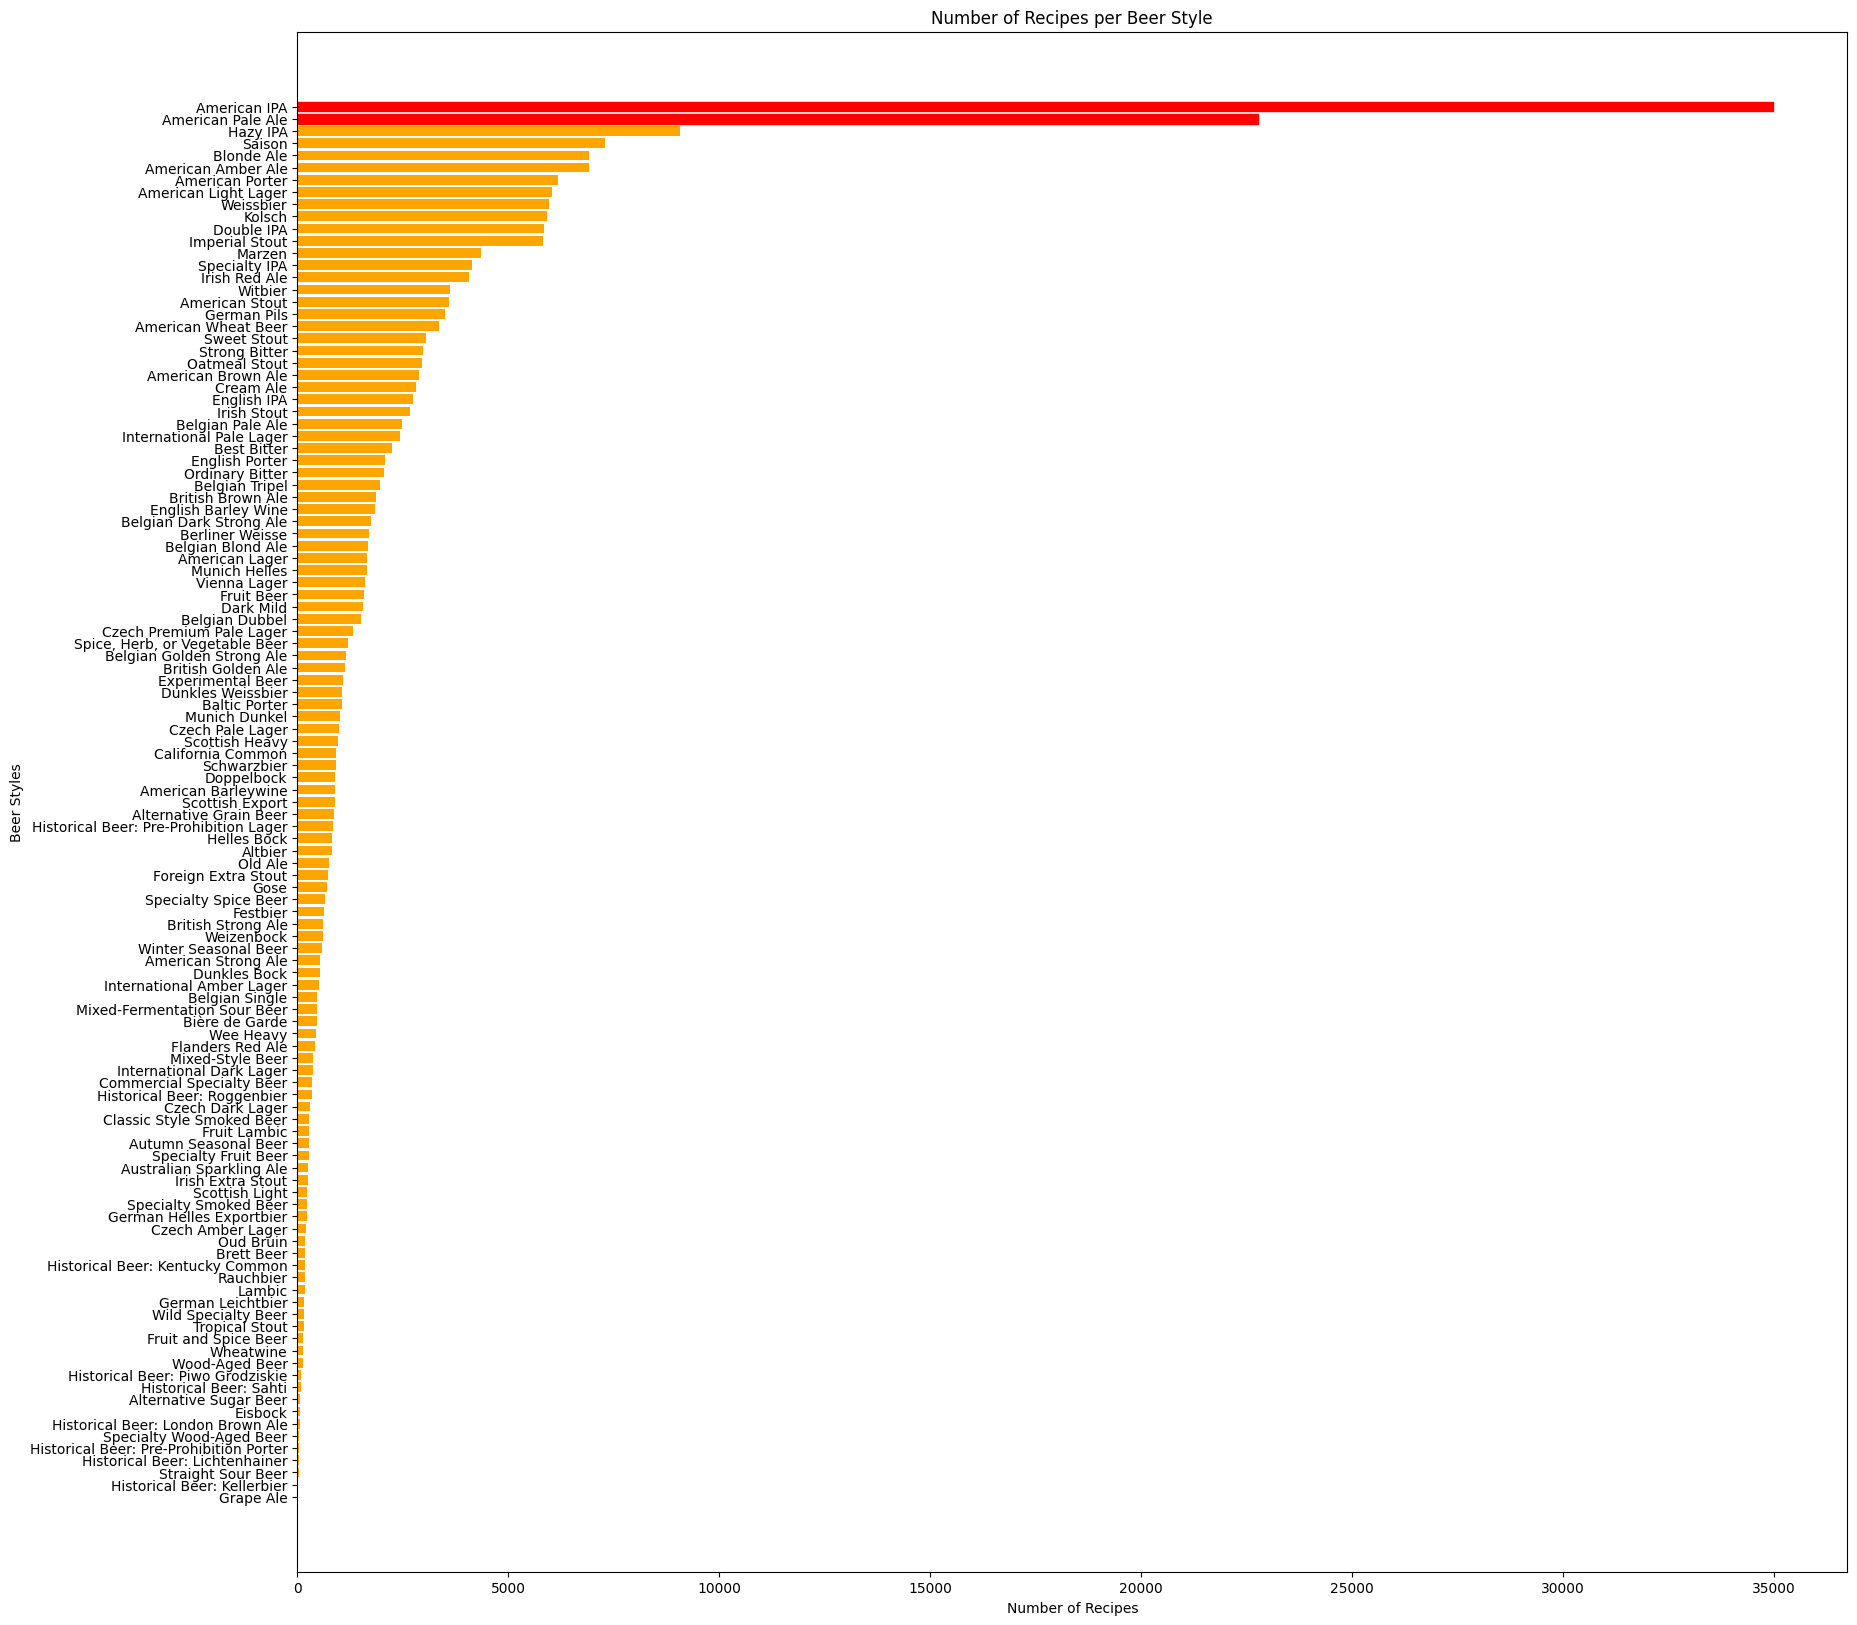

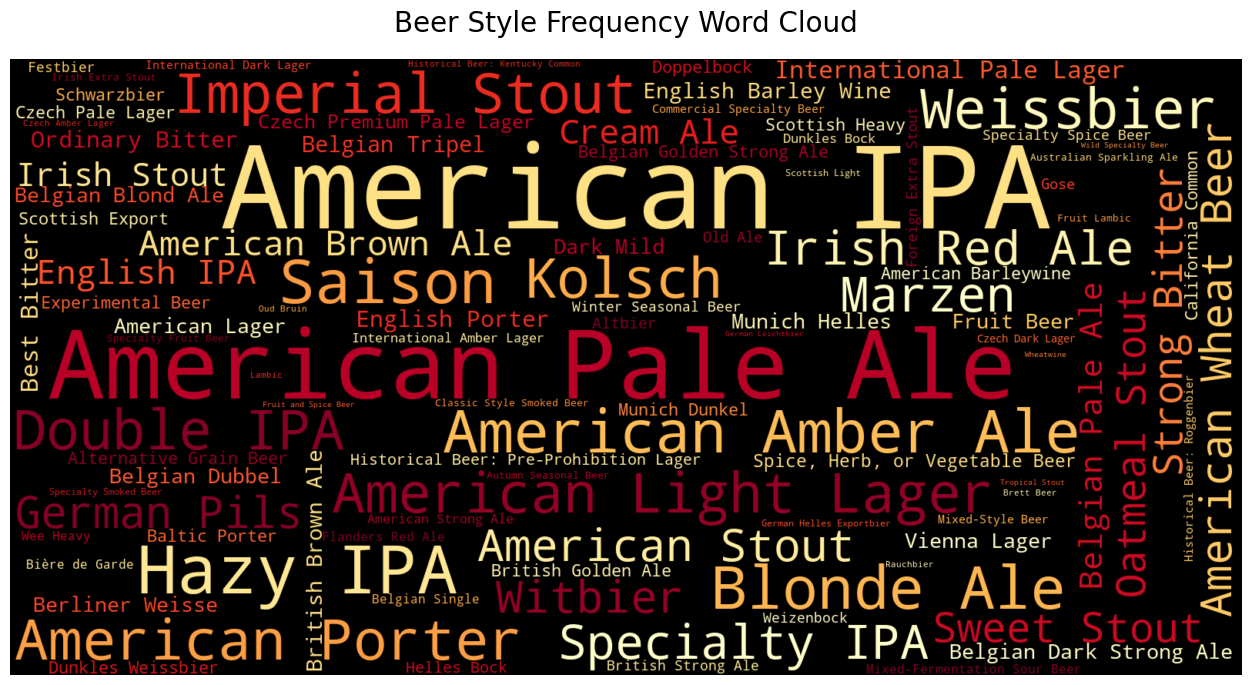

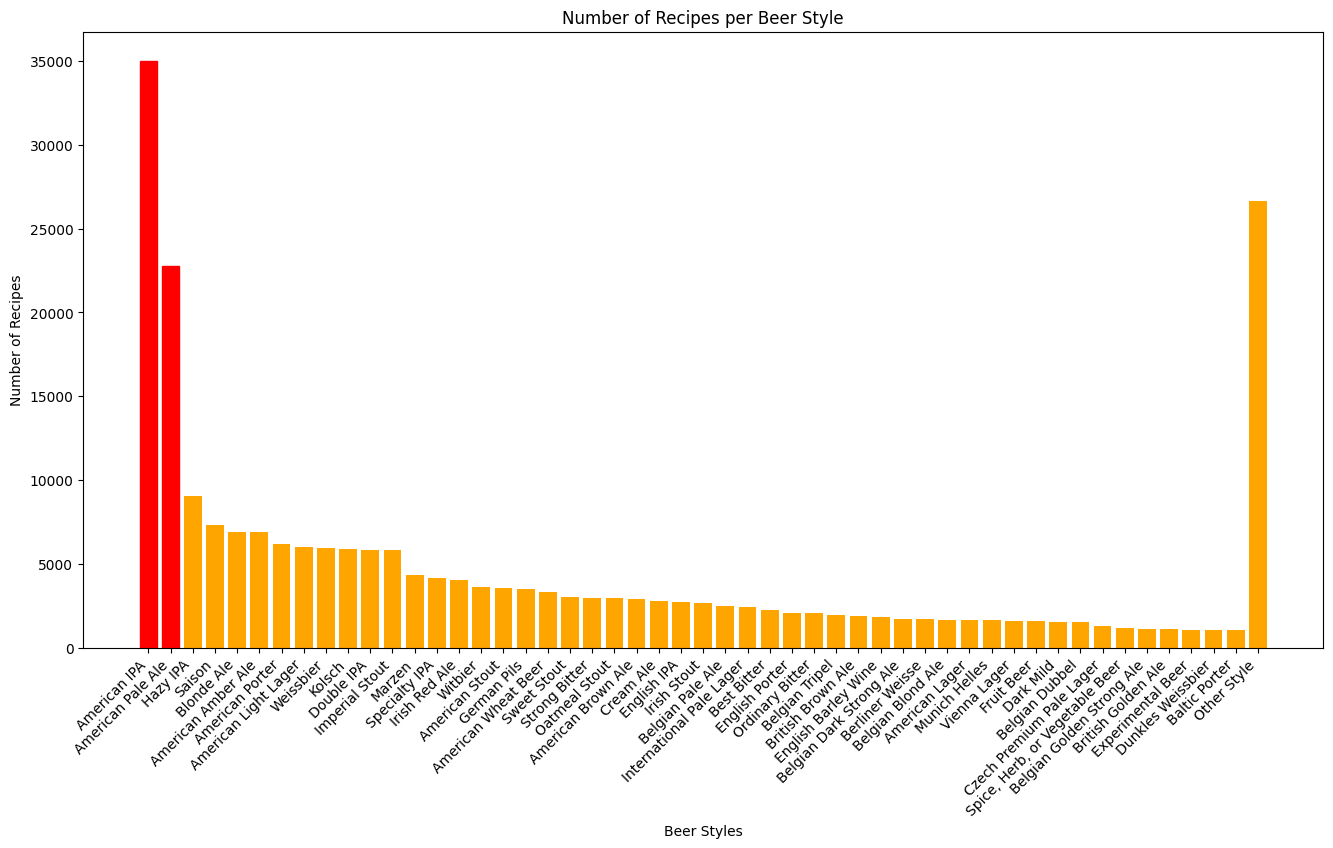

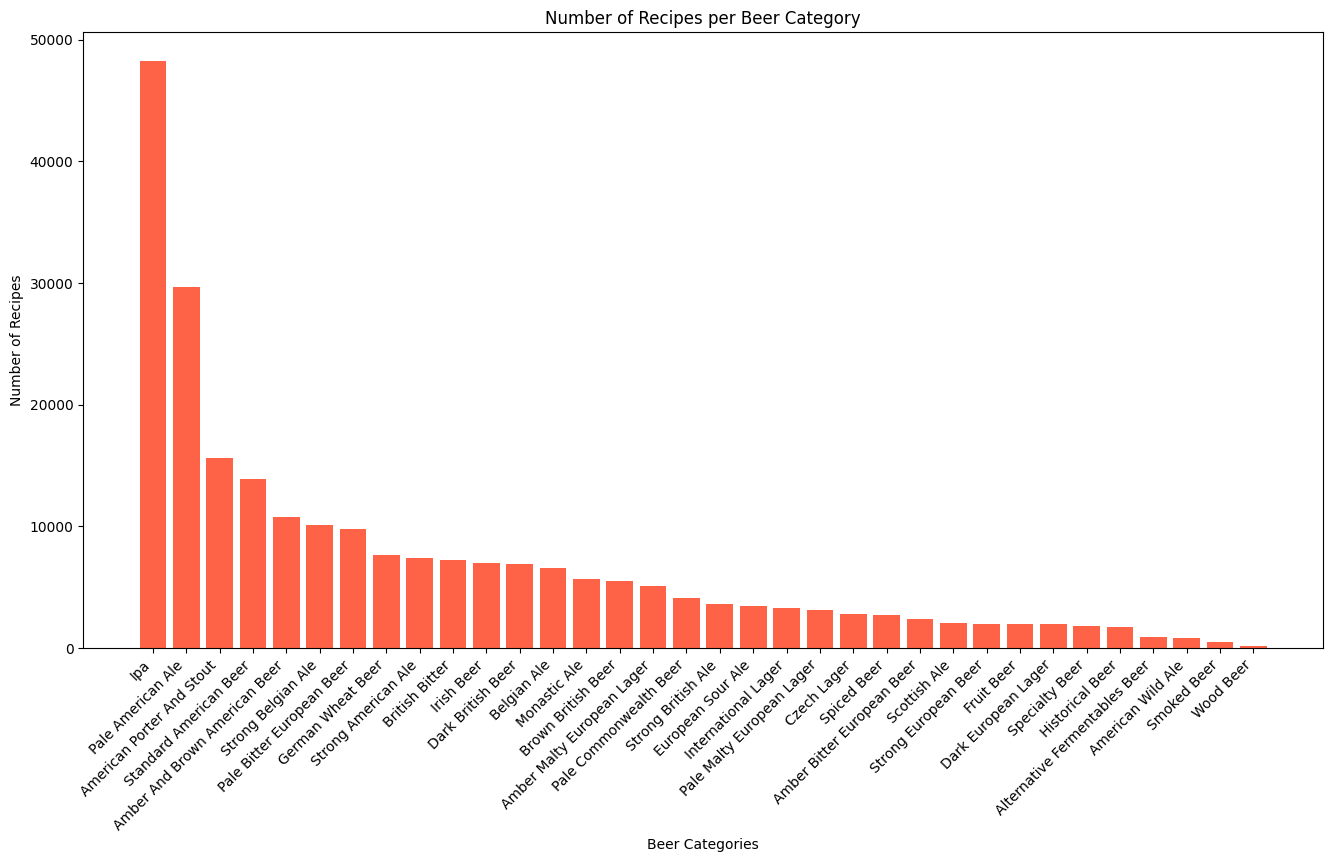

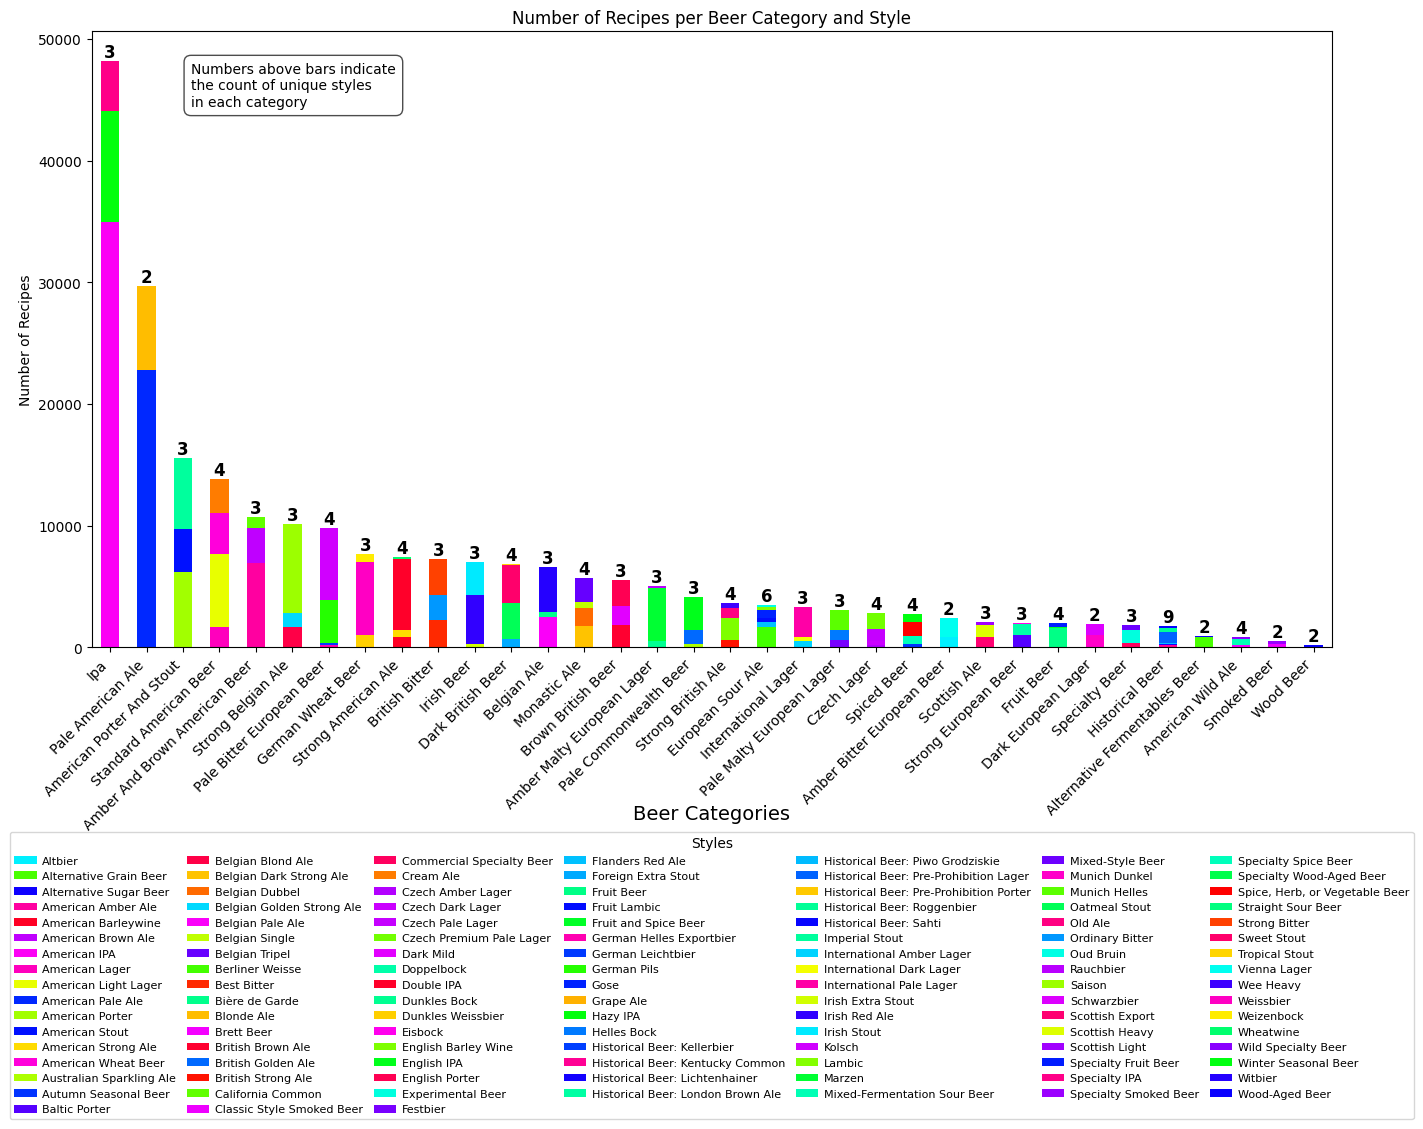

In [ ]:
# Visualization 1: Call the Horizontal bar chart of the frequency of recipes by Style
total_occurrence(beer_recipes)  # Pass the DataFrame as an argument

# Visualization 2: Create the word cloud
create_beer_wordcloud(beer_recipes)

# Visualization 3: The **Top 50** beer styles in a vertical bar chart
total_occurrence_abbrev_v(beer_recipes)

# Visualization 4: Number of Recipes per Category
plot_category_counts(beer_recipes)

# Visualization 5: Call the Stacked Bar Chart 
plot_category_style_distribution(beer_recipes)  # Pass the DataFrame as an argument

#Visualization 6: Calculate and Call the Compliance Table
summary_table = create_and_display_compliance_summary(beer_recipes, styles_2021_cleaned)

#Visualization 7: Call the Compliance Heatmap
create_compliance_heatmap(summary_table)